In [4]:
import uproot
import awkward as ak


In [5]:
path = "/data/delphes_bkg_output.root"
tree = uproot.open(path)["Delphes"]

branches = ["Muon.PT", "Muon.Eta", "Jet.PT", "Jet.Eta", "MissingET.MET"]
arrays = tree.arrays(branches, library="ak")

print("Branches loaded:")
for b in branches:
    print("  ", b)

print("\nNumber of events:", len(arrays["Muon.PT"]))

mu_counts = ak.num(arrays["Muon.PT"])
jet_counts = ak.num(arrays["Jet.PT"])

print("Average muons/event:", ak.mean(mu_counts))
print("Average jets/event :", ak.mean(jet_counts))

Branches loaded:
   Muon.PT
   Muon.Eta
   Jet.PT
   Jet.Eta
   MissingET.MET

Number of events: 50000
Average muons/event: 1.06936
Average jets/event : 0.59918


not flattened: [[47, 42.3], [10.1], [18.6], [54.5, 26.4], ..., [44.1, ...], [], [], [30.2]]
flattened: [47, 42.3, 10.1, 18.6, 54.5, 26.4, ..., 74.1, 22.8, 12.9, 44.1, 43.7, 30.2]
padded: [[47, 42.3, None, None], [10.1, None, ..., None], ..., [30.2, None, None, None]]
filled: [[47, 42.3, 0, 0], [10.1, 0, 0, 0], [...], ..., [0, 0, 0, 0], [30.2, 0, 0, 0]]


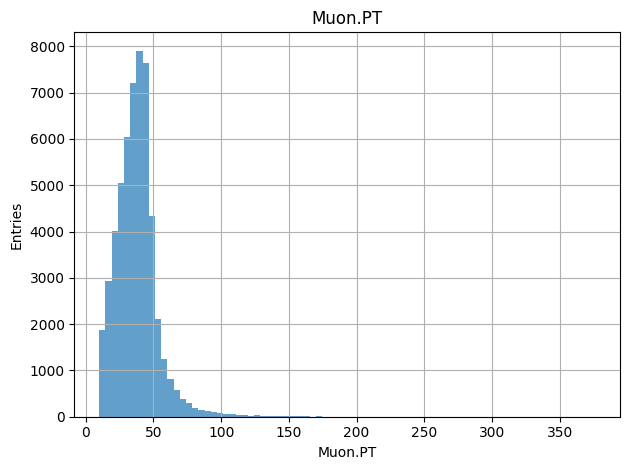

not flattened: [[0.405, -0.136], [-1.96], [-0.416], [-2.16, -2.43], ..., [], [], [-1.68]]
flattened: [0.405, -0.136, -1.96, -0.416, -2.16, ..., -0.252, 0.641, -0.0566, 0.451, -1.68]
padded: [[0.405, -0.136, None, None], [-1.96, ...], ..., [-1.68, None, None, None]]
filled: [[0.405, -0.136, 0, 0], [-1.96, 0, 0, 0], ..., [0, 0, ..., 0], [-1.68, 0, 0, 0]]


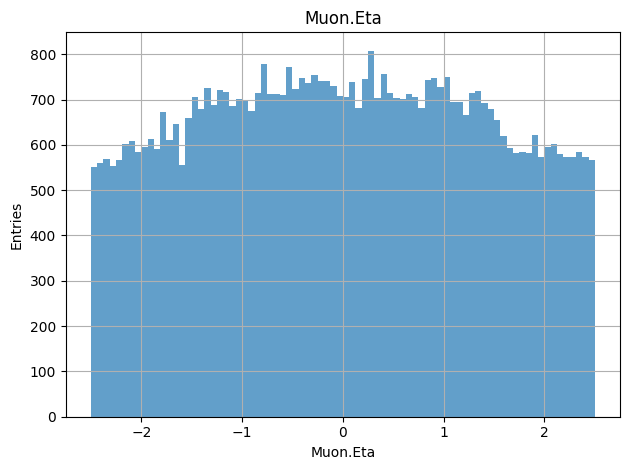

not flattened: [[], [], [], [24.8], [], [], [], [], ..., [], [], [73.9], [], [], [], [], []]
flattened: [24.8, 25, 48.6, 35, 47.2, 44.8, 39.5, ..., 46.1, 31.2, 27.7, 32.5, 37, 73.9]
padded: [[None, None, None, None], [None, ..., None], ..., [None, None, None, None]]
filled: [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], ..., [0, 0, 0, 0], [0, 0, 0, 0]]


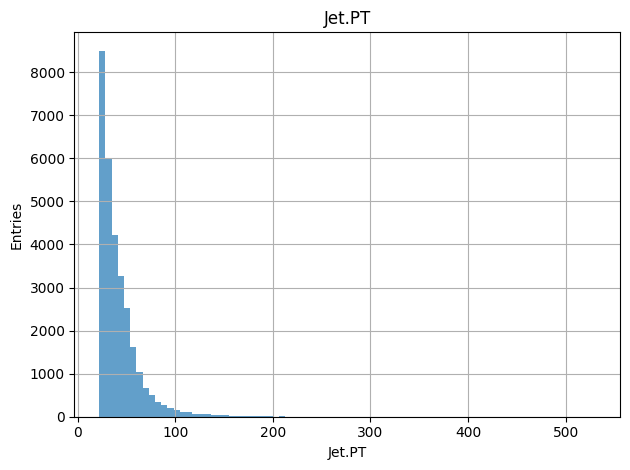

not flattened: [[], [], [], [-4.24], [], [], [], [], ..., [], [], [-0.351], [], [], [], [], []]
flattened: [-4.24, 1.18, 2.13, 4.08, 1.03, 2.41, ..., -0.201, -1.08, -0.454, -3.45, -0.351]
padded: [[None, None, None, None], [None, ..., None], ..., [None, None, None, None]]
filled: [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], ..., [0, 0, 0, 0], [0, 0, 0, 0]]


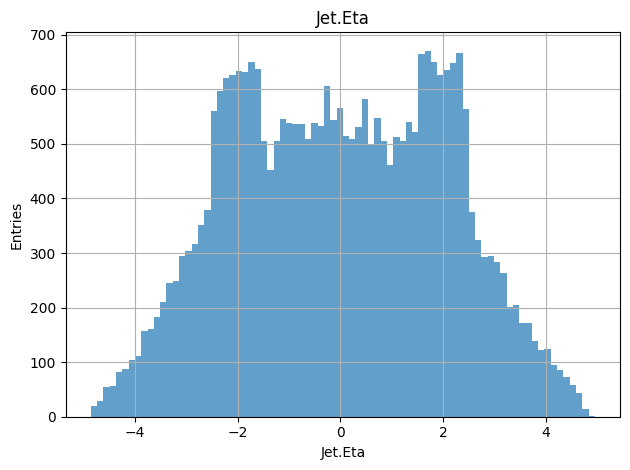

not flattened: [[1.1], [12], [23.5], [22], [6.47], ..., [6.55], [6.81], [14.3], [12.2], [23.6]]
flattened: [1.1, 12, 23.5, 22, 6.47, 10.5, 3.12, ..., 9.62, 6.55, 6.81, 14.3, 12.2, 23.6]
padded: [[1.1, None, None, None], [12, None, ..., None], ..., [23.6, None, None, None]]
filled: [[1.1, 0, 0, 0], [12, 0, 0, 0], [...], ..., [12.2, 0, 0, 0], [23.6, 0, 0, 0]]


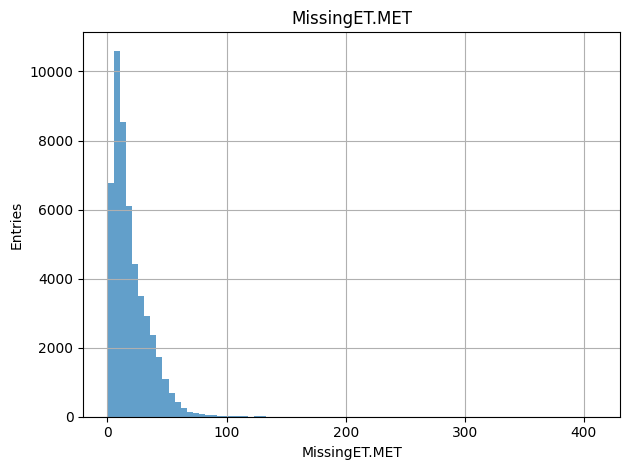

In [8]:
import matplotlib.pyplot as plt

for branch in branches:
    arr = arrays[branch]

    flat = ak.flatten(arr)
    print(f'not flattened: {arr}')
    print(f'flattened: {flat}')
    x = ak.to_numpy(flat)
    padded = ak.pad_none(arr, 4)
    filled = ak.fill_none(padded, 0)
    print(f'padded: {padded}')
    print(f'filled: {filled}')
    plt.figure()
    plt.hist(x, bins=80, alpha=0.7)
    plt.title(branch)
    plt.xlabel(branch)
    plt.ylabel("Entries")
    plt.grid(True)
    plt.tight_layout()
    plt.show()